In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr
import statsmodels.api as sm
# import gdown # this is for importing into google collab. not needed otherwise.

------------------------------------------------------------------------------------------------------------------------


# Checking the dataset to see how clean it is

In [52]:
df = pd.read_csv("student_lifestyle_dataset.csv")
print(df.shape)
df.head()

(2000, 8)


,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA,Stress_Level
0,1,6.9,3.8,8.7,2.8,1.8,2.99,Moderate
1,2,5.3,3.5,8.0,4.2,3.0,2.75,Low
2,3,5.1,3.9,9.2,1.2,4.6,2.67,Low
3,4,6.5,2.1,7.2,1.7,6.5,2.88,Moderate
4,5,8.1,0.6,6.5,2.2,6.6,3.51,High


In [53]:
df.isna().sum()

Student_ID                         0
Study_Hours_Per_Day                0
Extracurricular_Hours_Per_Day      0
Sleep_Hours_Per_Day                0
Social_Hours_Per_Day               0
Physical_Activity_Hours_Per_Day    0
GPA                                0
Stress_Level                       0
dtype: int64

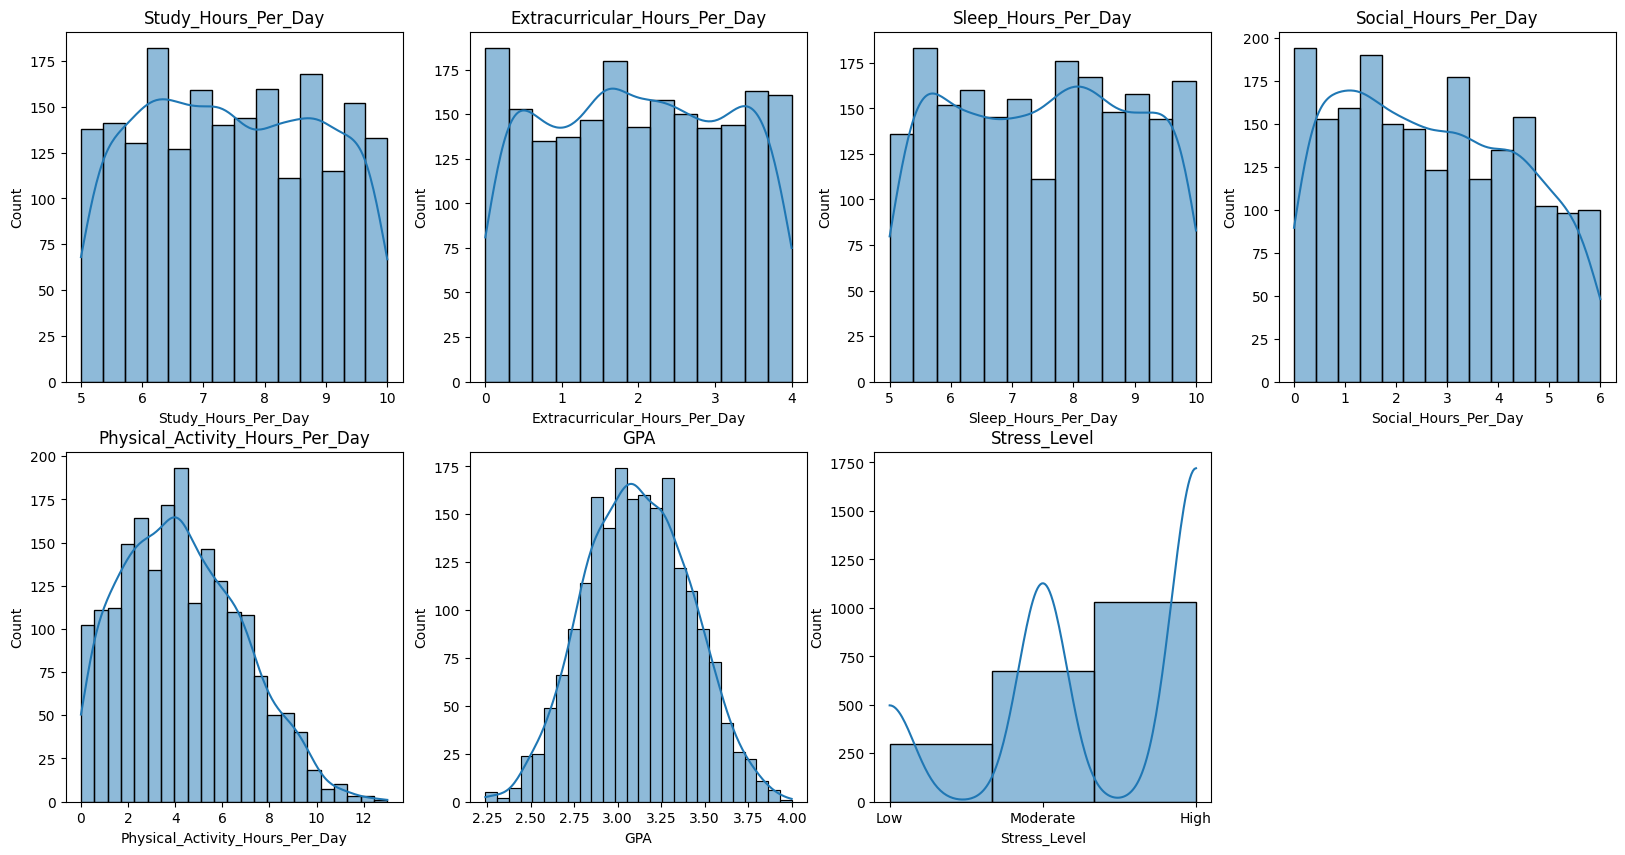

Student_ID                         0.000000
Study_Hours_Per_Day                0.034988
Extracurricular_Hours_Per_Day      0.001263
Sleep_Hours_Per_Day               -0.007096
Social_Hours_Per_Day               0.184222
Physical_Activity_Hours_Per_Day    0.399239
GPA                                0.027516
dtype: float64

In [54]:
#histograms for all the columns
columns_list = 'Study_Hours_Per_Day', 'Extracurricular_Hours_Per_Day','Sleep_Hours_Per_Day', 'Social_Hours_Per_Day','Physical_Activity_Hours_Per_Day', 'GPA'
fig, ax = plt.subplots(2, 4, figsize=(20, 10))
ax = ax.flatten()
for i, col in enumerate(columns_list):
  # using sns cuz it has the KDE line so we can see skewness better
  sns.histplot(df[col], edgecolor = 'black', ax = ax[i], kde = True)
  ax[i].set_title(col)

# stress level xticks were not in order so i manually did it outside the for loop
remap = {'Low': 1, 'Moderate': 2, 'High': 3}
temp = df['Stress_Level'].map(remap)
sns.histplot(temp, bins = 3, edgecolor = 'black', ax = ax[6], kde = True)
ax[6].set_xticks([1,2,3])
ax[6].set_xticklabels(['Low', 'Moderate', 'High'])
ax[6].set_title("Stress_Level")

fig.delaxes(ax[-1]) #deleting the spare subplot


plt.show()
df.skew(numeric_only=True) 

## NOTE ABOUT THE HISTOGRAMS

- "Stress Level" and "Physical Activity" are heaviliy skewed. 

- "Social hours" is slightly skewed

- Everything else is pretty symetric. 

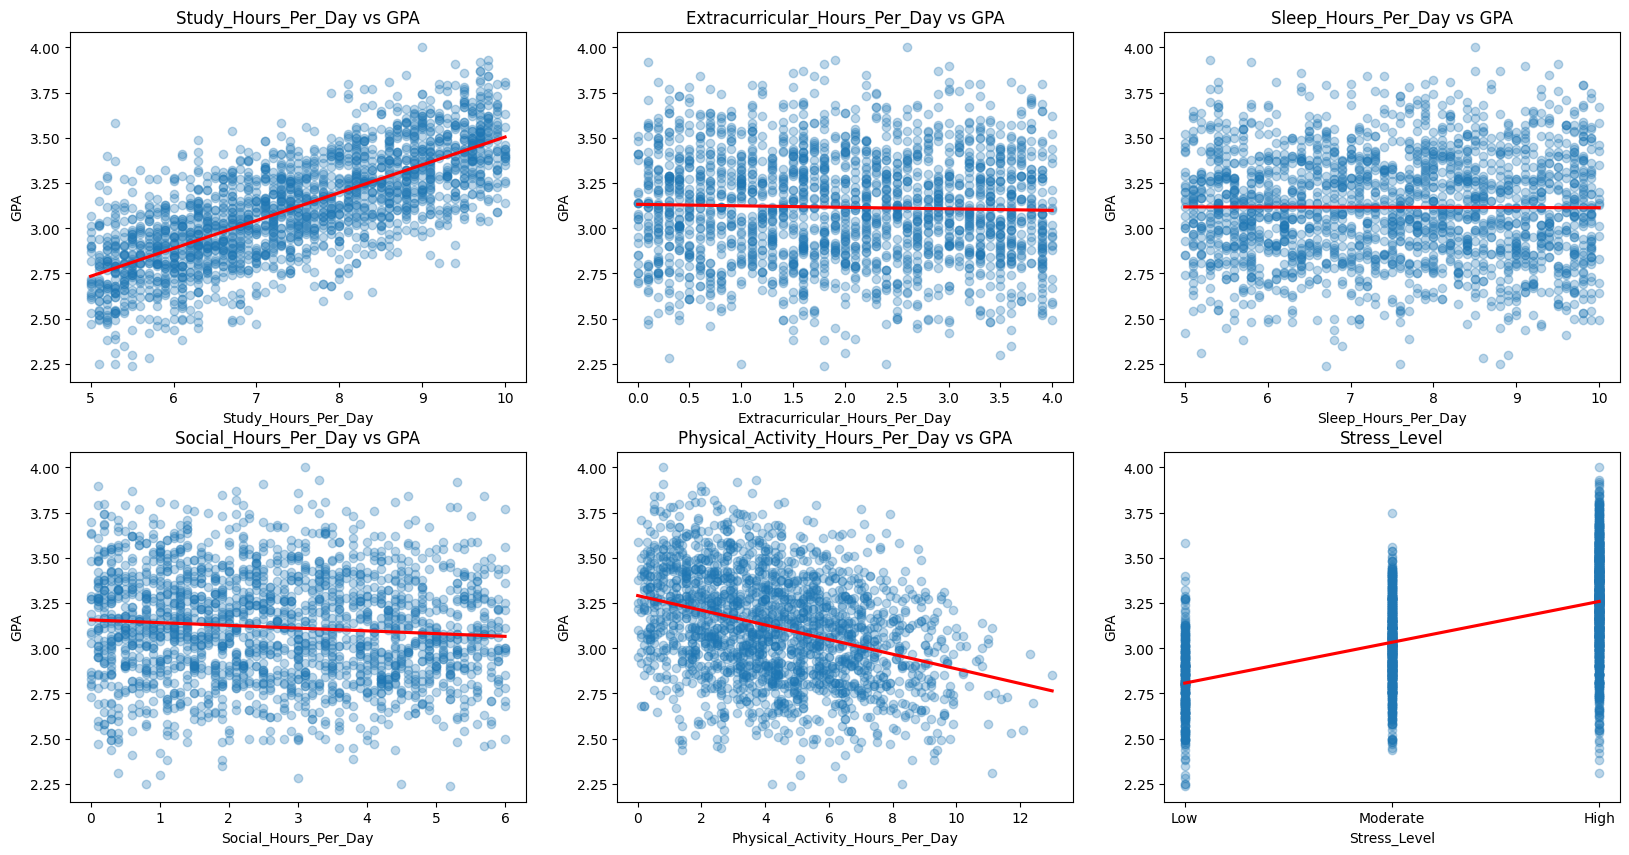

In [73]:
#scatterplots for all the columns against GPA
columns_list = 'Study_Hours_Per_Day', 'Extracurricular_Hours_Per_Day','Sleep_Hours_Per_Day', 'Social_Hours_Per_Day','Physical_Activity_Hours_Per_Day', 
fig, ax = plt.subplots(2, 3, figsize=(20, 10))
ax = ax.flatten()
for i, col in enumerate(columns_list):

  ax[i].scatter(x = df[col], y = df['GPA'], alpha = 0.3)
  sns.regplot(x=df[col], y= df['GPA'], scatter = False, color = 'red',ci=None, ax=ax[i])

  ax[i].set_xlabel(col)
  ax[i].set_ylabel('GPA')
  ax[i].set_title(f"{col} vs GPA") 

# doing the same thing for stress level cuz the xticks arent in order
remap = {'Low': 1, 'Moderate': 2, 'High': 3}
temp = df['Stress_Level'].map(remap)
ax[5].scatter(x = temp, y = df['GPA'], alpha = 0.3)
sns.regplot(x=temp, y= df['GPA'], scatter = False, color = 'red',ci=None, ax=ax[5])
ax[5].set_xlabel('Stress_Level')
ax[5].set_ylabel('GPA')
ax[5].set_xticks([1,2,3])
ax[5].set_xticklabels(['Low', 'Moderate', 'High'])
ax[5].set_title("Stress_Level")

plt.show()

In [56]:
# doing this so can i can see stress_level on the correlation matrix

df['Stress_Levels_numeric'] = df['Stress_Level'].map({
    'Low': 1,
    'Moderate': 2,
    'High': 3
})


In [57]:
print(df.columns.tolist())

['Student_ID', 'Study_Hours_Per_Day', 'Extracurricular_Hours_Per_Day', 'Sleep_Hours_Per_Day', 'Social_Hours_Per_Day', 'Physical_Activity_Hours_Per_Day', 'GPA', 'Stress_Level', 'Stress_Levels_numeric']


Text(0.5, 1.0, 'Correlation Heatmap')

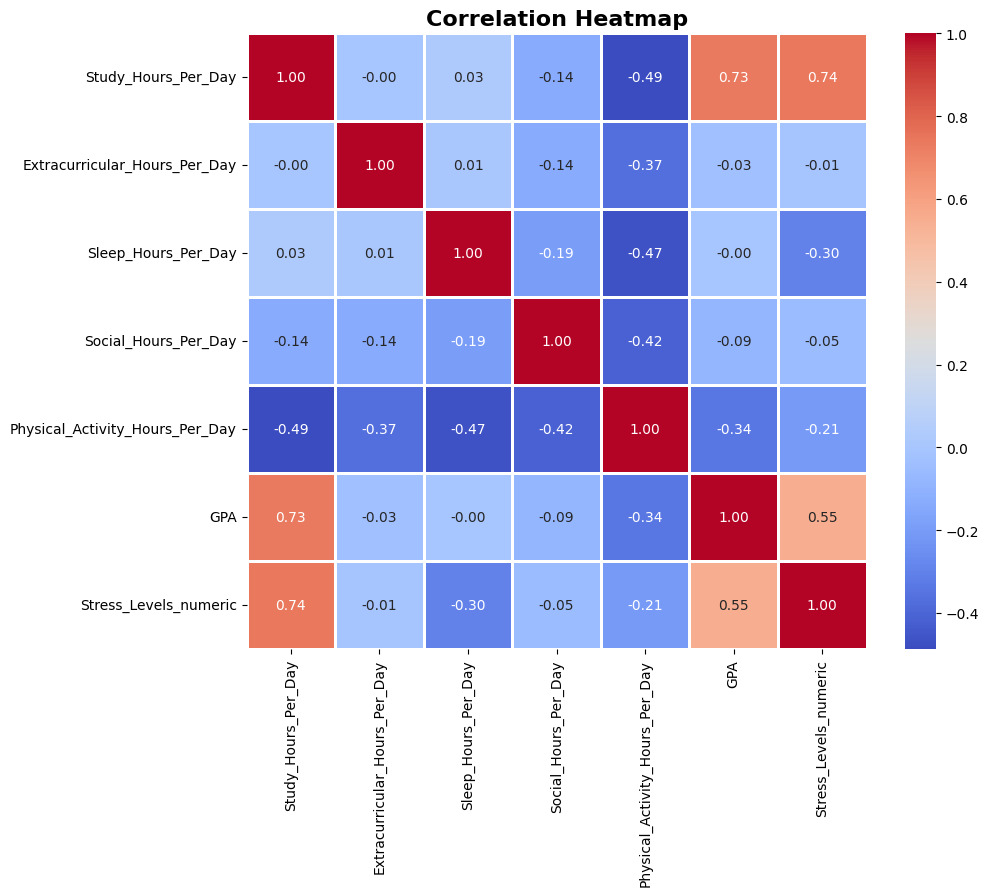

In [58]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(df[['Study_Hours_Per_Day', 'Extracurricular_Hours_Per_Day', 
                'Sleep_Hours_Per_Day', 'Social_Hours_Per_Day', 'Physical_Activity_Hours_Per_Day', 
                'GPA', 'Stress_Levels_numeric']].corr(),
                fmt = '.2f',
                  annot=True, 
                  cmap='coolwarm',
                    linecolor='white',
                    linewidths=1
                  )
ax.set_title("Correlation Heatmap", fontweight='bold', fontsize=16)


------------------------------------------------------------------------------------------------------------------------


# Investigating the Relationship between "Study_Hours and GPA"

pvalue: PearsonRResult(statistic=np.float64(0.7344679806560517), pvalue=np.float64(0.0))
correlation coeff 0.7344679806560518


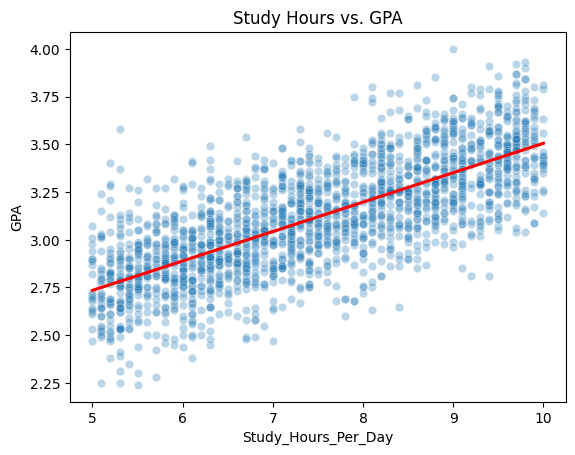

In [59]:
sns.scatterplot(x=df['Study_Hours_Per_Day'], y= df['GPA'], alpha=0.3)

sns.regplot(x=df['Study_Hours_Per_Day'], y= df['GPA'], scatter = False, color = 'red',ci=None)
plt.xlabel('Study_Hours_Per_Day')
plt.ylabel('GPA')
plt.title("Study Hours vs. GPA")

print("pvalue:",pearsonr(df['Study_Hours_Per_Day'], df['GPA'])) 
print("correlation coeff",df['Study_Hours_Per_Day'].corr(df['GPA']))

## NOTE FOR "STUDY HOURS VS. GPA"

Corr-coeff: 0.7344679806560518

P-value: 0.0

Positive slope for the trend line, high positive correlation (r=0.73), and p-value is really low (p < 0.01)

This all indicates that students that study more tend to get a higher gpa. 

------------------------------------------------------------------------------------------------------------------------


# Investigating the Relationship between "Sleep_Hours" vs "GPA"

pvalue PearsonRResult(statistic=np.float64(-0.0042784409489437705), pvalue=np.float64(0.8483540570887685))
correlation coeff: -0.004278440948943774


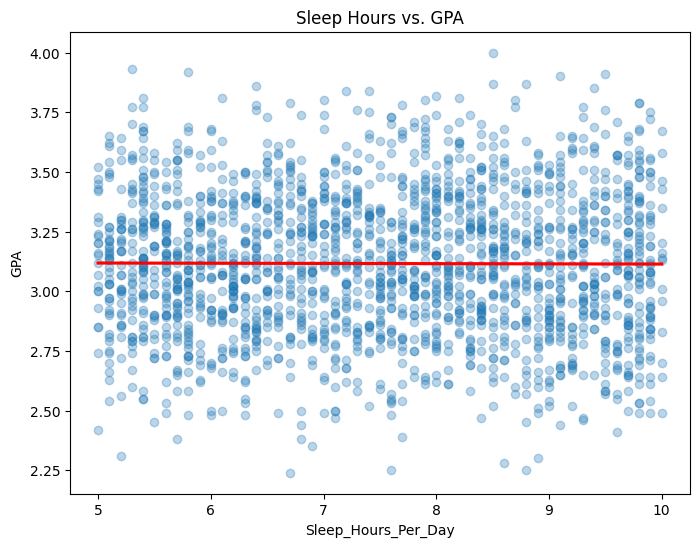

In [60]:
fig, ax = plt.subplots(figsize = (8, 6))
ax.scatter(df['Sleep_Hours_Per_Day'], df['GPA'], alpha = 0.3) # couldnt get seaborn to work but this does so fuck it

sns.regplot(x=df['Sleep_Hours_Per_Day'], y= df['GPA'], scatter = False, color = 'red', ci=None)
plt.xlabel('Sleep_Hours_Per_Day')
plt.ylabel('GPA')
plt.title("Sleep Hours vs. GPA")

print("pvalue",pearsonr(df['Sleep_Hours_Per_Day'], df['GPA']))
print("correlation coeff:",df['Sleep_Hours_Per_Day'].corr(df['GPA'])) 

## NOTE FOR "SLEEP HOURS VS. GPA"

Corr-coeff: -0.004278440948943774

P-value: ~0.84

The trend line is basically flat, the p-value is really high and the correlation is basically 0. This indicates no meaningful relationship. 

Thought it is important to note that the lower end of the range we are working with is 5 hours. There is no information for the lower values.

------------------------------------------------------------------------------------------------------------------------


# Investigating the Relationship between "Physical Activity" vs "GPA"

pvalue: PearsonRResult(statistic=np.float64(-0.3411524640099619), pvalue=np.float64(1.08098835621249e-55))
correlation coeff -0.341152464009962


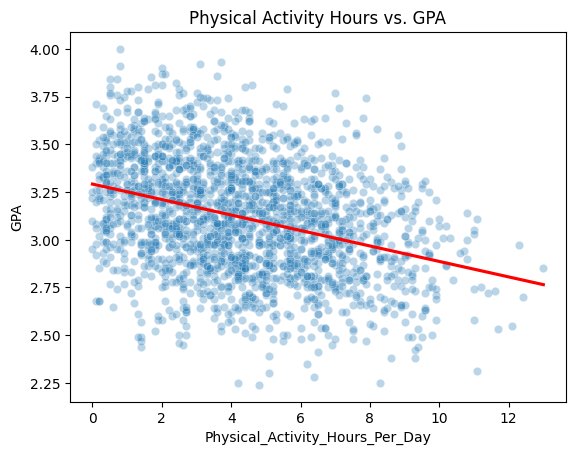

In [76]:
sns.scatterplot(x=df['Physical_Activity_Hours_Per_Day'], y= df['GPA'], alpha=0.3)

sns.regplot(x=df['Physical_Activity_Hours_Per_Day'], y= df['GPA'], scatter = False, color = 'red', ci=None)
plt.xlabel('Physical_Activity_Hours_Per_Day')
plt.ylabel('GPA')
plt.title("Physical Activity Hours vs. GPA")

print("pvalue:",pearsonr(df['Physical_Activity_Hours_Per_Day'], df['GPA'])) 
print("correlation coeff",df['Physical_Activity_Hours_Per_Day'].corr(df['GPA']))

In [62]:
X = df[['Study_Hours_Per_Day', 'Physical_Activity_Hours_Per_Day', ]]
y = df['GPA']
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    GPA   R-squared:                       0.540
Model:                            OLS   Adj. R-squared:                  0.539
Method:                 Least Squares   F-statistic:                     1171.
Date:                Tue, 31 Mar 2026   Prob (F-statistic):               0.00
Time:                        00:58:46   Log-Likelihood:                 355.61
No. Observations:                2000   AIC:                            -705.2
Df Residuals:                    1997   BIC:                            -688.4
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const     

## Note for "Physical Activity" vs "GPA"

corr-coeff = -0.341152464009962
p-value = 1.08098835621249e-55

When putting "Physical activity" with "Study Hours" into an OLS regression, "Physical activity" becomes no longer statistically significant. Keeping in mind that "Physical activity" is also heavily skewed, I don't wanna go too far in depth in an isolated investigation of the variable. Putting it into a OLS regression later on with more variables is most likely gonna be a better option.

------------------------------------------------------------------------------------------------------------------------


# Investigating the Relationship between "Stress_Level" and "GPA"


Text(0.5, 1.0, 'Stress Level vs. GPA')

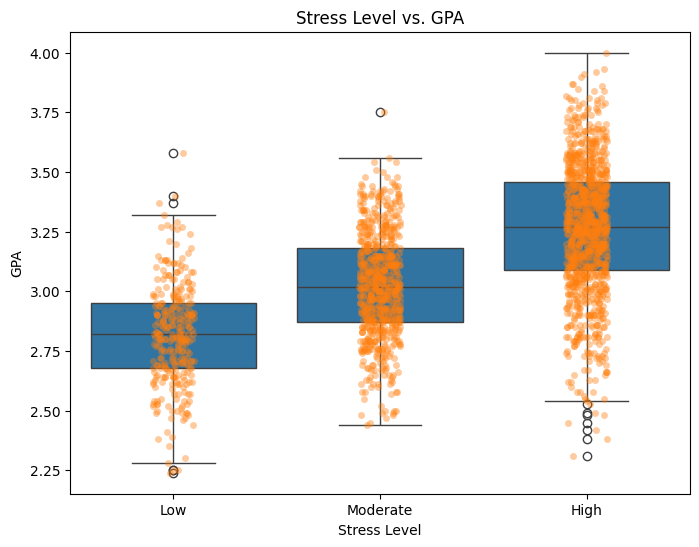

In [63]:
plt.figure(figsize=(8, 6))

sns.boxplot(x='Stress_Level', y='GPA', data=df, order=["Low", "Moderate", "High"])
sns.stripplot(x='Stress_Level', y='GPA', data=df, alpha=0.4, order=["Low", "Moderate", "High"])

plt.xlabel("Stress Level")
plt.ylabel("GPA")
plt.title("Stress Level vs. GPA")

### Checking the relationship between "Study hours" and "Stress Levels" 

Just checking this before concluding anything about stress levels and gpa

pvalue: PearsonRResult(statistic=np.float64(0.7388432058141347), pvalue=np.float64(0.0))
correlation coeff 0.7388432058141353


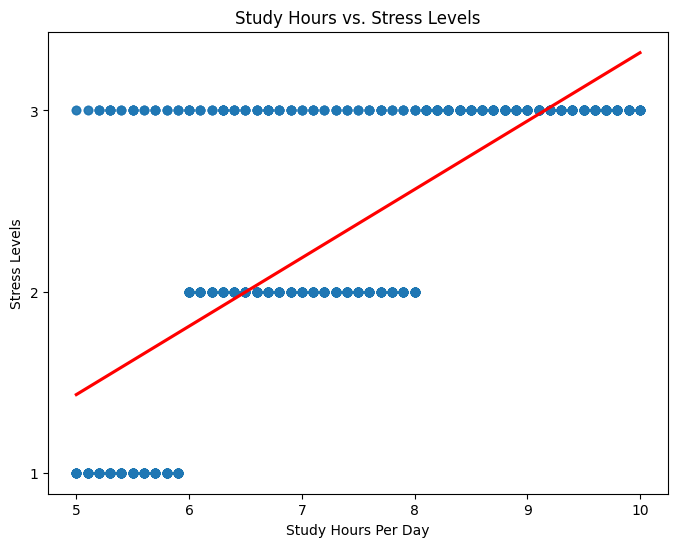

In [64]:
fig, ax = plt.subplots(figsize = (8, 6))
ax.scatter(x = df['Study_Hours_Per_Day'], y = df['Stress_Levels_numeric'], alpha = 0.6)
sns.regplot(y=df['Stress_Levels_numeric'], x= df['Study_Hours_Per_Day'], scatter = False, color = 'red', ci=None)
plt.xlabel("Study Hours Per Day")
plt.ylabel("Stress Levels")
plt.yticks([1, 2, 3])
plt.title("Study Hours vs. Stress Levels")

print("pvalue:", pearsonr(df['Stress_Levels_numeric'], df['Study_Hours_Per_Day']))
print("correlation coeff",df['Stress_Levels_numeric'].corr(df['Study_Hours_Per_Day']))

In [65]:
X = pd.get_dummies(df[['Study_Hours_Per_Day', 'Stress_Level']], drop_first=True)
X = X.astype(float)
y = df['GPA']
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    GPA   R-squared:                       0.541
Model:                            OLS   Adj. R-squared:                  0.540
Method:                 Least Squares   F-statistic:                     782.6
Date:                Tue, 31 Mar 2026   Prob (F-statistic):               0.00
Time:                        00:58:47   Log-Likelihood:                 357.06
No. Observations:                2000   AIC:                            -706.1
Df Residuals:                    1996   BIC:                            -683.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     1.99

## Notes for "Stress Levels" vs. "GPA"

Corr-coeff: 0.550

P-value: 8.726002021727317e-159 (basically 0)

The slope of the trend line is positive, the p-value is low (p < 0.01), and the correlation coefficient is moderately high (r = 0.55)

This would normally indicate that students that are more stressed get higher grades. However, upon looking that the relationship between "Study hours" and "Stress Levels" as well as putting both into a multiple linear regression, it is clear that stress levels does not have a significant impact on GPA. While it is highly correlated with GPA, it most likely isn't the cause of it considering how study hours is highly correlated with both stress levels and GPA

------------------------------------------------------------------------------------------------------------------------


# Creating the Study_hour ratio variables 

In [66]:
df['Study:Sleep'] = df['Study_Hours_Per_Day'] / df['Sleep_Hours_Per_Day']

# # FIX THESE. THIS HAVE DIVIDE BY ZERO ERRORS SO THEY ARE INFINITE
# df['Study:Physical_Activity'] = df['Study_Hours_Per_Day'] / df['Physical_Activity_Hours_Per_Day']
# df['Study:Social'] = df['Study_Hours_Per_Day'] / df['Social_Hours_Per_Day']

# np.isinf(df[['Study:Sleep', 'Study:Physical_Activity', 'Study:Social']]).sum()

# Investigating the Relationship between "Study to Sleep ratio" and GPA 

<Axes: xlabel='Study:Sleep', ylabel='Count'>

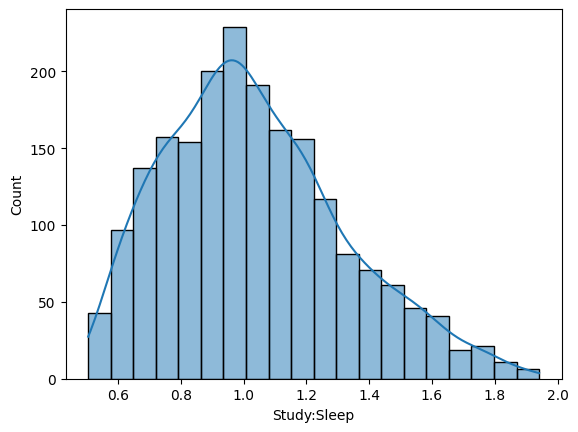

In [67]:
sns.histplot(df['Study:Sleep'], bins=20, kde=True)

pvalue: PearsonRResult(statistic=np.float64(0.49944224742671434), pvalue=np.float64(1.1508083251527664e-126))
correlation coeff 0.4994422474267142


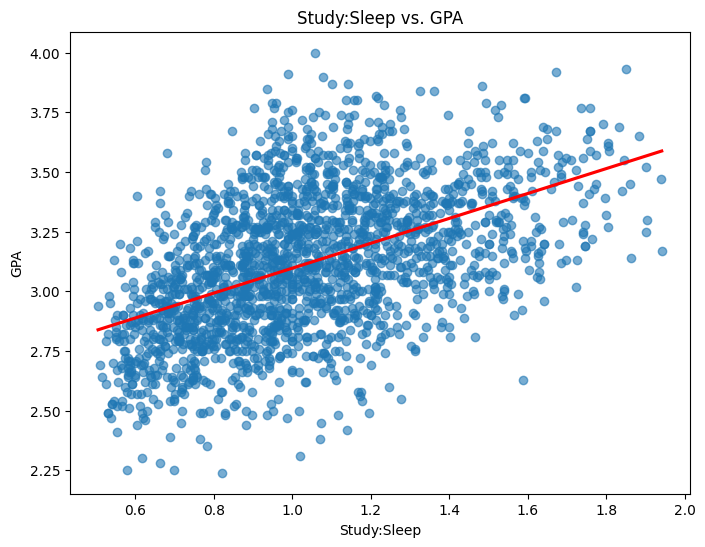

In [68]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df['Study:Sleep'], df['GPA'], alpha=0.6)
sns.regplot(x=df['Study:Sleep'], y=df['GPA'], scatter=False, color='red',ci=None)
plt.xlabel('Study:Sleep')
plt.ylabel('GPA')
plt.title("Study:Sleep vs. GPA")    


print("pvalue:", pearsonr(df['Study:Sleep'], df['GPA']))
print("correlation coeff",df['Study:Sleep'].corr(df['GPA']))

In [69]:
print("Study:Sleep correlation coeff:",df['Study:Sleep'].corr(df['GPA']))
print("Study Hours Per Day correlation coeff:",df['Study_Hours_Per_Day'].corr(df['GPA']))

X = df[['Study_Hours_Per_Day', 'Study:Sleep']]
y = df['GPA']
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

Study:Sleep correlation coeff: 0.4994422474267142
Study Hours Per Day correlation coeff: 0.7344679806560518
                            OLS Regression Results                            
Dep. Variable:                    GPA   R-squared:                       0.540
Model:                            OLS   Adj. R-squared:                  0.539
Method:                 Least Squares   F-statistic:                     1171.
Date:                Tue, 31 Mar 2026   Prob (F-statistic):               0.00
Time:                        00:58:47   Log-Likelihood:                 355.50
No. Observations:                2000   AIC:                            -705.0
Df Residuals:                    1997   BIC:                            -688.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
--------------

## Notes for "Study:Sleep" vs. "GPA"

Corr-coeff: 0.49 

P-value: 1.1508083251527664e-126 (basically 0)

When looking at the trend line of the scatterplot and the p-value/correlattion coeffiecients, The Study to Sleep ratio looks like a good predictor/variable for GPA. However, the correlation coefficient for Study_Hours_Per_Day alone is significantly higher than the Study to Sleep ratio. Upon putting both into a linear regression model, it shows that the p-value for the Study to Sleep ratio is high (p = 0.222) while Study_Hours_Per_Day was still significant with a very low p-value (p < 0.001).

This indicates that the correlation coefficient for Study:Sleep was highly inflated by study time rather than a balance between study hours and sleep hours.

------------------------------------------------------------------------------------------------------------------------


In [70]:
X = pd.get_dummies(df[['Study_Hours_Per_Day',
         'Physical_Activity_Hours_Per_Day', 
         'Social_Hours_Per_Day',
         'Stress_Level']],
           drop_first=True)
X = X.astype(float)
y = df['GPA']
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    GPA   R-squared:                       0.542
Model:                            OLS   Adj. R-squared:                  0.540
Method:                 Least Squares   F-statistic:                     471.2
Date:                Tue, 31 Mar 2026   Prob (F-statistic):               0.00
Time:                        00:58:47   Log-Likelihood:                 359.52
No. Observations:                2000   AIC:                            -707.0
Df Residuals:                    1994   BIC:                            -673.4
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const     

In [71]:
# Compute VIF for each feature
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)

                           feature         VIF
0                            const  208.188152
1              Study_Hours_Per_Day    3.862452
2  Physical_Activity_Hours_Per_Day    2.236203
3             Social_Hours_Per_Day    1.612902
4                 Stress_Level_Low    2.561352
5            Stress_Level_Moderate    1.807013


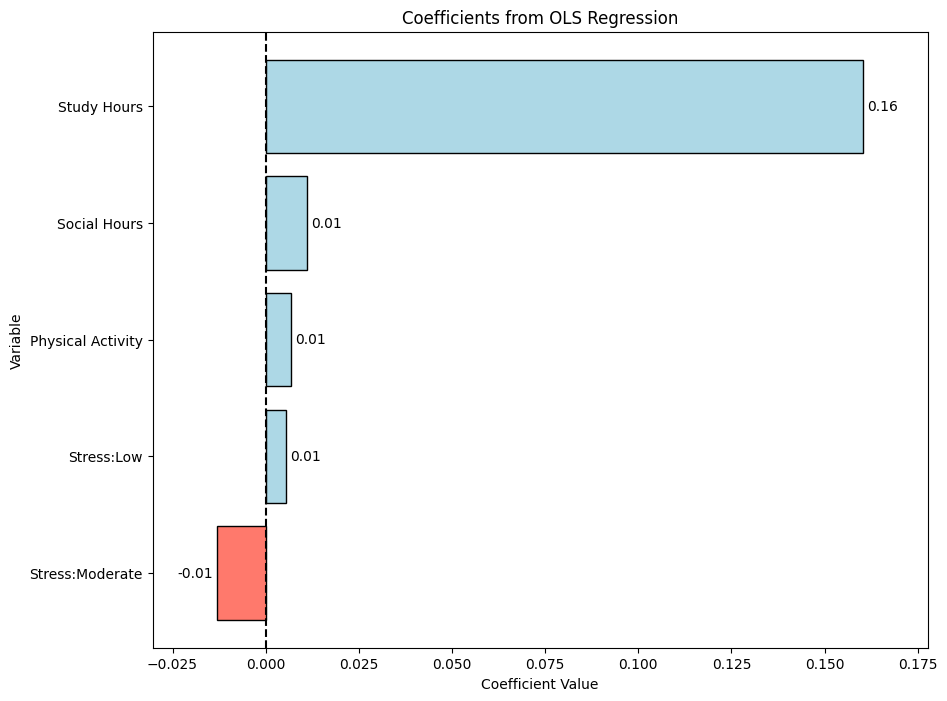

In [ ]:
coeffs = pd.DataFrame(model.params.drop('const'), columns=['Coefficient'])
coeffs

coeffs.sort_values(by='Coefficient', inplace=True, ascending=True)
fig, ax = plt.subplots(figsize=(10, 8))

# the salmon hexcode is from the documentation of this barh color (salmon)
bar_color = ["#FF796C" if i < 0 else "lightblue" for i in coeffs.values]

bars = ax.barh(coeffs.index, coeffs['Coefficient'], color = bar_color, edgecolor='black')
ax.bar_label(bars, labels = coeffs['Coefficient'].round(2).astype(str), padding = 3)
ax.axvline(0, color='black', linestyle='--')
ax.set_xlabel('Coefficient Value')
ax.set_yticks(range(len(coeffs.index)))
ax.set_yticklabels(['Stress:Moderate', 'Stress:Low',  'Physical Activity','Social Hours', 'Study Hours'])
ax.set_ylabel("Variable")
ax.set_title('Coefficients from OLS Regression')
ax.margins(x = 0.1)
plt.show()

In [135]:
lst = ['Study Hours', 'Physical Activity', 'Social Hours', 'Stress:Low', 'Stress:Moderate']
lst2 = []
for i in range(len(lst)):
    lst2.append(lst[-i-1])
print(lst2)

['Stress:Moderate', 'Stress:Low', 'Social Hours', 'Physical Activity', 'Study Hours']


## Notes about this OLS regression

- Study hours is statistically significant and has a positive effect on GPA (coeff = 0.1603, p < 0.001). This makes study hours the most positive relationship with GPA.

- Physical activity (coeff = 0.0054, p = 0.047) and Social Hours (coeff = 0.0068, p = 0.048) are both statistically significant and have a positive effect on GPA. However, considering the very small coefficients, it is most likely that it is not practically significant.  

- Stress level is not statistically significant according for the regression. However, this may be due unobserved factors that were not included in this analysis, the limited variation in the stress variable (perhaps a 1-10 scale wouldve been better), and also the heavy skewness of our data on the stress levels.